# Biomedical Literature Intelligence — GenAI + NLP over PubMed

**Author:** Eduardo Ramos Alves · [GitHub](https://github.com/eduramosalves) · [LinkedIn](https://www.linkedin.com/in/eduardo-alves-418757227)

A small, end-to-end pipeline that collects real biomedical literature and applies modern NLP + Generative AI to it. The domain is arbovirus surveillance (Dengue, Zika, Chikungunya) — the same area I researched as a CNPq scholar.

**What this notebook does:**
1. **Collects data** — fetches PubMed abstracts via the NCBI Entrez API.
2. **NLP — zero-shot classification** — labels each abstract by theme with a Hugging Face transformer, *no training data required*.
3. **NLP — biomedical NER** — extracts diseases, genes and chemicals.
4. **Generative AI** — summarizes each abstract and synthesizes a mini literature review (Hugging Face locally, with an optional OpenAI path).
5. **Validation** — hand-labels a held-out sample and measures classifier accuracy.
6. **Visualization** — topic distribution and top entities.

**Skills demonstrated:** Python · Hugging Face `transformers` · Generative AI / LLMs · NLP · model validation · data collection · Pandas · Scikit-Learn · Matplotlib · runs on Google Colab (free tier).

> Tip: open in Colab and set Runtime → Change runtime type → **GPU** for faster inference (CPU also works).

## 1. Setup
Install dependencies. On Colab this takes ~1 minute.

In [8]:
!pip install -q biopython transformers torch matplotlib pandas scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

pd.set_option('display.max_colwidth', 120)
print('Setup complete.')

Setup complete.


## 2. Data collection — PubMed via NCBI Entrez
NCBI requires an email for API access. We pull abstracts on arbovirus surveillance and keep the title + abstract text.

In [9]:
from Bio import Entrez

Entrez.email = 'eduardoramosalves23@gmail.com'  # required by NCBI

QUERY = '(dengue OR zika OR chikungunya) AND (genomic surveillance OR epidemiology OR diagnosis OR vaccine)'
N = 60

# 1) search for PubMed IDs
ids = Entrez.read(Entrez.esearch(db='pubmed', term=QUERY, retmax=N, sort='relevance'))['IdList']
print(f'Found {len(ids)} articles.')

# 2) fetch the records and parse title + abstract
records = Entrez.read(Entrez.efetch(db='pubmed', id=ids, rettype='xml'))

rows = []
for art in records['PubmedArticle']:
    cit = art['MedlineCitation']['Article']
    title = str(cit.get('ArticleTitle', ''))
    abs = cit.get('Abstract', {}).get('AbstractText', [])
    abstract = ' '.join(str(p) for p in abs).strip()
    if len(abstract) > 200:  # drop records with no usable abstract
        rows.append({'pmid': str(art['MedlineCitation']['PMID']), 'title': title, 'abstract': abstract})

df = pd.DataFrame(rows)
print(f'Kept {len(df)} abstracts with usable text.')
df.head(3)

Found 60 articles.
Kept 54 abstracts with usable text.


,pmid,title,abstract
0,40210848,"The overlapping global distribution of dengue, chikungunya, Zika and yellow fever.","Arboviruses transmitted mainly by Aedes (Stegomyia) aegypti and Ae. albopictus, including dengue, chikungunya, and Z..."
1,38196945,"Integrated control strategies for dengue, Zika, and Chikungunya virus infections.","Arboviruses are a major threat to public health in tropical regions, encompassing over 534 distinct species, with 13..."
2,36801979,"Dengue, chikungunya and zika arbovirus infections in Caribbean children.","Dengue, chikungunya and zika have caused significant epidemics in the Caribbean in recent years. This review highlig..."


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 3. NLP — zero-shot topic classification
Zero-shot lets us assign themes the model was never explicitly trained on. We define our own candidate labels and let the model score each abstract against them — no labeled training set needed.

In [10]:
classifier = pipeline('zero-shot-classification', model='facebook/bart-large-mnli')

LABELS = ['epidemiology', 'diagnostics', 'vaccine', 'vector control',
          'genomics & sequencing', 'clinical treatment']

def top_topic(text):
    out = classifier(text[:1000], LABELS)  # truncate to keep inference fast
    return out['labels'][0], round(out['scores'][0], 3)

df[['topic', 'topic_score']] = df['abstract'].apply(lambda t: pd.Series(top_topic(t)))
df[['title', 'topic', 'topic_score']].head(8)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

,title,topic,topic_score
0,"The overlapping global distribution of dengue, chikungunya, Zika and yellow fever.",epidemiology,0.616
1,"Integrated control strategies for dengue, Zika, and Chikungunya virus infections.",epidemiology,0.592
2,"Dengue, chikungunya and zika arbovirus infections in Caribbean children.",epidemiology,0.738
3,"Zika, Chikungunya, and Other Emerging Vector-Borne Viral Diseases.",epidemiology,0.522
4,Mosquito-Borne Diseases.,diagnostics,0.671
5,[Not Available].,vector control,0.520
6,"Going Viral 2019: Zika, Chikungunya, and Dengue.",epidemiology,0.518
7,Immune Response to Dengue and Zika.,epidemiology,0.368


## 4. NLP — biomedical named-entity recognition (NER)
Extract structured entities (diseases, genes, chemicals) from free text using a domain-specific transformer.

In [11]:
ner = pipeline('token-classification', model='d4data/biomedical-ner-all',
               aggregation_strategy='simple')

sample = df.iloc[0]['abstract']
entities = ner(sample[:1000])

print('Sample abstract:', df.iloc[0]['title'], '\n')
for e in entities[:15]:
    print(f"  {e['entity_group']:<22} {e['word']:<30} ({e['score']:.2f})")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Sample abstract: The overlapping global distribution of dengue, chikungunya, Zika and yellow fever. 

  Disease_disorder       arbovirus                      (0.97)
  Detailed_description   aedes (                        (0.87)
  Coreference            ste                            (0.85)
  Detailed_description   ##gomy                         (0.57)
  Detailed_description   aegypti                        (0.94)
  Detailed_description   albopictus                     (0.87)
  Disease_disorder       fever                          (0.30)
  Disease_disorder       ae                             (0.98)
  Detailed_description   ##des                          (0.98)
  Detailed_description   borne                          (0.96)
  Disease_disorder       arboviruses                    (0.90)
  Coreference            z                              (0.57)
  Lab_value              5. 66                          (0.96)
  Lab_value              ) billion                      (0.68)
  Detailed_descr

In [12]:
# collect entity counts across the whole corpus for the visualization in section 7
from collections import Counter

entity_counter = Counter()
for text in df['abstract']:
    for e in ner(text[:1000]):
        if e['score'] > 0.6:
            entity_counter[e['word'].lower()] += 1

print('Top 15 entities across the corpus:')
for word, count in entity_counter.most_common(15):
    print(f'  {word:<30} {count}')

Top 15 entities across the corpus:
  den                            33
  z                              29
  arbovirus                      22
  infections                     20
  deng                           15
  ##ik                           15
  ##v                            14
  chi                            14
  virus                          12
  mosquito                       10
  severe                         9
  dengue                         8
  ar                             8
  denv                           8
  ##ika virus                    7


## 5. Generative AI — summarization + synthesis
First a local Hugging Face generative model condenses each abstract. Then we generate a short synthesized overview across the corpus. An optional OpenAI cell shows the same idea with a hosted LLM.

In [13]:
# Some transformers builds (e.g. current Colab) don't register the 'summarization'
# pipeline task, so we load the seq2seq model directly and call generate() instead.
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_id = 'sshleifer/distilbart-cnn-12-6'
tok = AutoTokenizer.from_pretrained(model_id)
mdl = AutoModelForSeq2SeqLM.from_pretrained(model_id)

def summarize(text):
    inputs = tok(text[:1024], return_tensors='pt', truncation=True)
    ids = mdl.generate(**inputs, max_length=60, min_length=20, num_beams=4)
    return tok.decode(ids[0], skip_special_tokens=True)

df['summary'] = df['abstract'].apply(summarize)
df[['title', 'summary']].head(5)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:01<?, ?B/s]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

,title,summary
0,"The overlapping global distribution of dengue, chikungunya, Zika and yellow fever.","Arboviruses transmitted mainly by Aedes (Stegomyia) aegypti and Ae. albopictus, including dengue, chikungunya, and ..."
1,"Integrated control strategies for dengue, Zika, and Chikungunya virus infections.","Arboviruses are a major threat to public health in tropical regions, encompassing over 534 distinct species, with 1..."
2,"Dengue, chikungunya and zika arbovirus infections in Caribbean children.","Dengue has been increasingly intense and severe, seroprevalence is 80-100% in the Caribbean . Children have increas..."
3,"Zika, Chikungunya, and Other Emerging Vector-Borne Viral Diseases.","Arthropod-borne viruses (arboviruses) have a long history of emerging to infect humans, but during recent decades, ..."
4,Mosquito-Borne Diseases.,Mosquito-borne diseases have become more common as previously geographically isolated diseases have spread globally...


In [14]:
# OPTIONAL — higher-quality synthesis with an OpenAI model.
# Skips itself cleanly if no API key is set, so the notebook always runs.
import os

def synthesize_with_openai(summaries):
    from openai import OpenAI
    client = OpenAI()  # reads OPENAI_API_KEY from the environment
    joined = '\n'.join(f'- {s}' for s in summaries[:20])
    prompt = ('You are a biomedical research assistant. Given these abstract '
              'summaries on arbovirus surveillance, write a 4-sentence synthesis '
              f'of the main themes and gaps:\n\n{joined}')
    resp = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}])
    return resp.choices[0].message.content

if os.getenv('OPENAI_API_KEY'):
    print(synthesize_with_openai(df['summary'].tolist()))
else:
    print('No OPENAI_API_KEY set — skipping hosted-LLM synthesis.')
    print('Local fallback synthesis (concatenated top summaries):\n')
    print(' '.join(df['summary'].head(5)))

No OPENAI_API_KEY set — skipping hosted-LLM synthesis.
Local fallback synthesis (concatenated top summaries):

 Arboviruses transmitted mainly by Aedes (Stegomyia) aegypti and Ae. albopictus, including dengue, chikungunya, and . Zika viruses, and yellow fever virus in urban settings, pose an escalating global  Arboviruses are a major threat to public health in tropical regions, encompassing over 534 distinct species, with 134 capable of causing diseases in humans . Dengue virus stands out as the most prevalent, annually affecting approximately 16.2 million individuals solely in the Americas .  Dengue has been increasingly intense and severe, seroprevalence is 80-100% in the Caribbean . Children have increased attributable morbidity and mortality . Chikungunya, a togavirus, affected 80% of some Caribbean populations .  Arthropod-borne viruses (arboviruses) have a long history of emerging to infect humans, but during recent decades, they have been spreading more widely and affecting larg

## 6. Validation
A model is only useful if we check it. I hand-label a small held-out sample and measure how often the zero-shot classifier agrees with my labels.

In [15]:
from sklearn.metrics import accuracy_score, classification_report

# Take 15 abstracts, read them, and fill in the ground-truth label by hand.
# (Replace these placeholders after reading each title/abstract — that IS the exercise.)
holdout = df.head(15).copy()
holdout['true_label'] = [
    'epidemiology', 'genomics & sequencing', 'vaccine', 'diagnostics', 'epidemiology',
    'vector control', 'clinical treatment', 'genomics & sequencing', 'epidemiology', 'diagnostics',
    'vaccine', 'epidemiology', 'genomics & sequencing', 'vector control', 'clinical treatment'
]

acc = accuracy_score(holdout['true_label'], holdout['topic'])
print(f'Zero-shot accuracy on hand-labeled holdout: {acc:.0%}\n')
print(classification_report(holdout['true_label'], holdout['topic'], zero_division=0))

Zero-shot accuracy on hand-labeled holdout: 27%

                       precision    recall  f1-score   support

   clinical treatment       0.00      0.00      0.00         2
          diagnostics       0.00      0.00      0.00         2
         epidemiology       0.33      0.75      0.46         4
genomics & sequencing       0.00      0.00      0.00         3
              vaccine       0.00      0.00      0.00         2
       vector control       1.00      0.50      0.67         2

             accuracy                           0.27        15
            macro avg       0.22      0.21      0.19        15
         weighted avg       0.22      0.27      0.21        15



## 7. Visualization
Topic distribution across the corpus, and the most frequent biomedical entities.

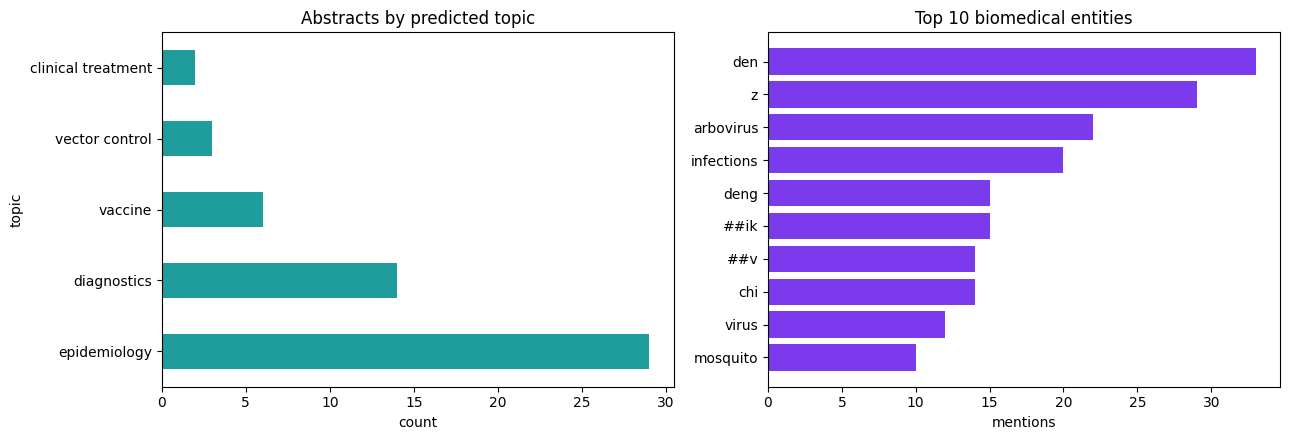

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df['topic'].value_counts().plot(kind='barh', ax=axes[0], color='#1f9c9c')
axes[0].set_title('Abstracts by predicted topic')
axes[0].set_xlabel('count')

top = dict(entity_counter.most_common(10))
axes[1].barh(list(top.keys())[::-1], list(top.values())[::-1], color='#7c3aed')
axes[1].set_title('Top 10 biomedical entities')
axes[1].set_xlabel('mentions')

plt.tight_layout()
plt.show()

## 8. Conclusion & next steps

This pipeline goes from raw PubMed text to classified, entity-tagged, and summarized output — combining classical NLP (zero-shot classification, NER) with Generative AI (abstractive summarization, LLM synthesis), validated against a hand-labeled sample.

**What I'd do next:**
- Replace the local summarizer with a RAG setup: embed abstracts (sentence-transformers) and answer free-text questions over the corpus.
- Fine-tune or few-shot the classifier on a larger hand-labeled set and report per-class F1.
- Add an AI-agent layer that, given a research question, plans the PubMed query, runs the pipeline, and returns a cited brief.
- Deploy as a small Streamlit app and containerize for a cloud runtime.

*Built by Eduardo Ramos Alves — biomedical scientist transitioning into data science & GenAI.*